In [3]:
import sqlite3
import pandas as pd


In [4]:
conn = sqlite3.connect("../data/raw/database.db")

In [5]:
df = pd.read_sql_query("SELECT * FROM player_stats", conn)

In [6]:
df.head()


,replay_id,rank,rank_tier,team,duration,core_shots,core_shots_against,core_goals,core_goals_against,core_saves,...,positioning_percent_defensive_half,positioning_percent_offensive_half,positioning_percent_behind_ball,positioning_percent_infront_ball,positioning_percent_most_back,positioning_percent_most_forward,positioning_percent_closest_to_ball,positioning_percent_farthest_from_ball,demo_inflicted,demo_taken
0,a6f42ba3-db4a-40b3-9e93-f2f53fed78b8,gold-1,7,blue,352,3,7,1,3,4,...,67.363420,32.636578,68.834600,31.165396,38.962980,33.401110,33.431015,39.830150,1,0
1,a6f42ba3-db4a-40b3-9e93-f2f53fed78b8,gold-1,7,blue,352,4,7,1,3,0,...,63.878620,36.121380,67.854500,32.145500,35.135456,40.577717,41.026253,35.374676,0,0
2,a6f42ba3-db4a-40b3-9e93-f2f53fed78b8,gold-1,7,blue,352,0,7,0,3,1,...,72.992640,27.007362,66.273860,33.726140,41.983130,26.403923,32.922672,41.145866,1,0
3,a6f42ba3-db4a-40b3-9e93-f2f53fed78b8,gold-1,7,orange,352,4,7,2,2,2,...,67.410965,32.589030,76.462166,23.537832,28.377490,35.643800,32.653550,29.812809,0,0
4,a6f42ba3-db4a-40b3-9e93-f2f53fed78b8,gold-1,7,orange,352,2,7,1,2,2,...,71.707240,28.292767,77.792305,22.207690,38.185513,31.248129,36.929607,35.883020,0,0


In [7]:
df.shape

(1518, 89)

In [8]:
df["rank_tier"].value_counts().sort_index()

rank_tier
7     102
8     102
9     102
10    102
11    102
12    102
13    102
14    102
15    102
16    102
17    102
18    102
19    102
20    102
21     90
Name: count, dtype: int64

In [9]:
df.isna().sum().sort_values(ascending=False).head(20)

positioning_goals_against_while_last_defender    692
rank                                               0
rank_tier                                          0
team                                               0
duration                                           0
core_shots                                         0
core_shots_against                                 0
core_goals                                         0
replay_id                                          0
core_saves                                         0
core_assists                                       0
core_score                                         0
core_mvp                                           0
core_shooting_percentage                           0
boost_bpm                                          0
boost_bcpm                                         0
boost_avg_amount                                   0
boost_amount_collected                             0
boost_amount_stolen                           

In [10]:
df.groupby("rank_tier")["positioning_goals_against_while_last_defender"].apply(lambda x: x.isna().sum())

rank_tier
7     44
8     46
9     40
10    54
11    50
12    45
13    52
14    50
15    48
16    42
17    36
18    53
19    41
20    48
21    43
Name: positioning_goals_against_while_last_defender, dtype: int64

In [11]:
df.groupby("rank_tier")["positioning_goals_against_while_last_defender"].apply(lambda x: (x == 0).sum())

rank_tier
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
Name: positioning_goals_against_while_last_defender, dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 89 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   replay_id                                       1518 non-null   str    
 1   rank                                            1518 non-null   str    
 2   rank_tier                                       1518 non-null   int64  
 3   team                                            1518 non-null   str    
 4   duration                                        1518 non-null   int64  
 5   core_shots                                      1518 non-null   int64  
 6   core_shots_against                              1518 non-null   int64  
 7   core_goals                                      1518 non-null   int64  
 8   core_goals_against                              1518 non-null   int64  
 9   core_saves                                      1518

In [13]:
df.describe()

,rank_tier,duration,core_shots,core_shots_against,core_goals,core_goals_against,core_saves,core_assists,core_score,core_mvp,...,positioning_percent_defensive_half,positioning_percent_offensive_half,positioning_percent_behind_ball,positioning_percent_infront_ball,positioning_percent_most_back,positioning_percent_most_forward,positioning_percent_closest_to_ball,positioning_percent_farthest_from_ball,demo_inflicted,demo_taken
count,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,...,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000
mean,13.944664,367.529644,2.232543,6.697628,0.729908,2.189723,1.102767,0.456522,315.389987,0.166667,...,65.135733,34.864267,72.072290,27.927710,34.533619,33.554731,33.539043,34.489539,0.863636,0.863636
std,4.293712,57.089633,1.564882,2.846341,0.825301,1.202985,1.091698,0.663896,139.029073,0.372801,...,7.435377,7.435377,5.460187,5.460187,7.649762,6.419401,5.655169,6.786727,1.392790,1.097361
min,7.000000,300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,40.056046,4.942372,42.586147,4.160156,13.397947,0.182983,1.829826,15.644053,0.000000,0.000000
25%,10.000000,336.000000,1.000000,5.000000,0.000000,1.000000,0.000000,0.000000,214.000000,0.000000,...,60.398869,29.925002,68.791769,24.370477,29.453471,29.261171,29.637885,30.001797,0.000000,0.000000
50%,14.000000,352.000000,2.000000,7.000000,1.000000,2.000000,1.000000,0.000000,303.000000,0.000000,...,64.872425,35.127573,72.410212,27.589790,34.042058,33.356119,33.402846,34.150285,1.000000,1.000000
75%,18.000000,373.000000,3.000000,8.000000,1.000000,3.000000,2.000000,1.000000,401.000000,0.000000,...,70.074998,39.601129,75.629526,31.208235,38.875534,37.553378,37.099317,38.693858,1.000000,1.000000
max,21.000000,676.000000,11.000000,18.000000,6.000000,7.000000,8.000000,4.000000,902.000000,1.000000,...,95.057630,59.943954,95.839840,57.413850,91.308330,68.268820,64.271870,66.740580,21.000000,8.000000


In [14]:
df.groupby("rank_tier")["movement_avg_speed"].mean()

rank_tier
7     1344.127451
8     1325.147059
9     1384.392157
10    1363.147059
11    1368.313725
12    1400.421569
13    1403.470588
14    1415.450980
15    1444.127451
16    1473.098039
17    1528.313725
18    1501.598039
19    1534.950980
20    1546.990196
21    1583.055556
Name: movement_avg_speed, dtype: float64

In [15]:
df.groupby("rank_tier")["boost_bpm"].mean()

rank_tier
7     261.196078
8     264.872549
9     291.735294
10    276.215686
11    294.176471
12    308.519608
13    309.617647
14    311.098039
15    331.872549
16    347.392157
17    372.656863
18    364.794118
19    396.401961
20    392.990196
21    414.344444
Name: boost_bpm, dtype: float64

In [16]:
rank_means = df.groupby("rank_tier").mean(numeric_only=True)

rank_means


,duration,core_shots,core_shots_against,core_goals,core_goals_against,core_saves,core_assists,core_score,core_mvp,core_shooting_percentage,...,positioning_percent_defensive_half,positioning_percent_offensive_half,positioning_percent_behind_ball,positioning_percent_infront_ball,positioning_percent_most_back,positioning_percent_most_forward,positioning_percent_closest_to_ball,positioning_percent_farthest_from_ball,demo_inflicted,demo_taken
rank_tier,,,,,,,,,,,,,,,,,,,,,
7,362.823529,1.735294,5.205882,0.794118,2.382353,0.637255,0.362745,263.147059,0.166667,36.454248,...,65.638781,34.361219,71.385933,28.614066,35.788059,33.877212,33.909584,35.625161,0.588235,0.588235
8,381.941176,2.000000,6.000000,0.774510,2.323529,0.862745,0.460784,289.245098,0.166667,32.049486,...,66.231797,33.768202,72.474445,27.525554,35.339754,33.855890,33.904963,35.223239,0.774510,0.774510
9,365.176471,1.921569,5.764706,0.862745,2.588235,0.794118,0.549020,297.127451,0.166667,37.418300,...,65.135133,34.864867,71.327817,28.672183,35.377512,33.832514,33.637750,35.327564,1.235294,1.235294
10,357.588235,1.862745,5.588235,0.715686,2.147059,0.735294,0.362745,272.745098,0.166667,28.562091,...,65.964631,34.035369,73.167879,26.832120,34.722010,33.638573,33.581297,34.680861,0.500000,0.500000
11,376.294118,2.225490,6.676471,0.764706,2.294118,0.990196,0.460784,310.872549,0.166667,32.444083,...,66.602650,33.397349,73.223678,26.776322,34.850469,33.698131,33.723828,34.881542,0.549020,0.549020
12,397.352941,2.245098,6.735294,0.686275,2.058824,1.186275,0.460784,326.088235,0.166667,30.450513,...,65.402354,34.597645,72.420803,27.579198,34.415123,33.649615,33.588701,34.407230,0.833333,0.833333
13,352.352941,1.950980,5.852941,0.627451,1.882353,1.029412,0.323529,283.843137,0.166667,31.944444,...,65.914914,34.085086,73.686547,26.313453,34.790650,33.801534,33.868550,34.684357,0.774510,0.774510
14,370.411765,2.137255,6.411765,0.676471,2.029412,1.147059,0.480392,324.852941,0.166667,28.905229,...,65.049954,34.950047,72.180736,27.819264,34.070041,33.491012,33.470511,34.063176,0.627451,0.627451
15,352.294118,2.274510,6.823529,0.715686,2.147059,1.137255,0.421569,311.803922,0.166667,29.493464,...,65.323090,34.676909,72.167154,27.832846,34.117663,33.298760,33.279709,34.048548,0.715686,0.715686


In [17]:
rank_means[[
    "core_score",
    "core_shots",
    "core_saves",
    "boost_bpm",
    "movement_avg_speed",
    "demo_inflicted"
]]

,core_score,core_shots,core_saves,boost_bpm,movement_avg_speed,demo_inflicted
rank_tier,,,,,,
7,263.147059,1.735294,0.637255,261.196078,1344.127451,0.588235
8,289.245098,2.000000,0.862745,264.872549,1325.147059,0.774510
9,297.127451,1.921569,0.794118,291.735294,1384.392157,1.235294
10,272.745098,1.862745,0.735294,276.215686,1363.147059,0.500000
11,310.872549,2.225490,0.990196,294.176471,1368.313725,0.549020
12,326.088235,2.245098,1.186275,308.519608,1400.421569,0.833333
13,283.843137,1.950980,1.029412,309.617647,1403.470588,0.774510
14,324.852941,2.137255,1.147059,311.098039,1415.450980,0.627451
15,311.803922,2.274510,1.137255,331.872549,1444.127451,0.715686


<Axes: xlabel='rank_tier'>

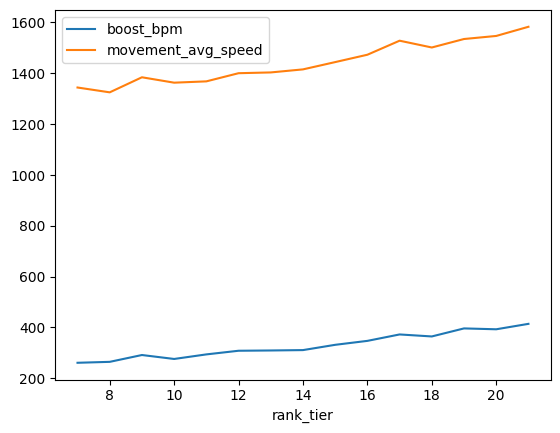

In [18]:
rank_means[["boost_bpm","movement_avg_speed"]].plot(kind="line")

<Axes: xlabel='rank_tier'>

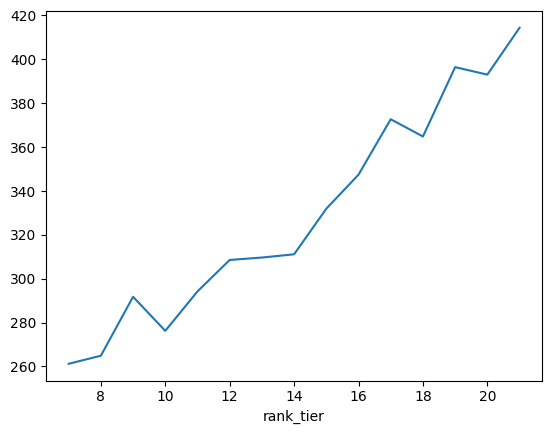

In [19]:
rank_means["boost_bpm"].plot(kind="line")

In [20]:
rank_correlations = df.corr(numeric_only=True)["rank_tier"].sort_values(ascending=False)

rank_correlations.head(40)

rank_tier                                         1.000000
movement_percent_high_air                         0.671777
movement_time_high_air                            0.643380
movement_avg_speed                                0.599000
movement_avg_speed_percentage                     0.599000
movement_percent_supersonic_speed                 0.581662
boost_bcpm                                        0.579207
boost_bpm                                         0.556803
movement_time_supersonic_speed                    0.548230
movement_count_powerslide                         0.510704
positioning_avg_distance_to_mates                 0.477501
boost_amount_collected                            0.467048
boost_amount_collected_big                        0.386575
movement_percent_low_air                          0.383850
boost_amount_collected_small                      0.382110
boost_count_collected_small                       0.381432
boost_amount_stolen                               0.3546

In [21]:
rank_correlations.tail(20)

positioning_percent_farthest_from_ball          -0.070735
positioning_time_most_back                      -0.073650
positioning_time_behind_ball                    -0.074021
positioning_time_farthest_from_ball             -0.078247
boost_percent_boost_25_50                       -0.079190
core_goals_against                              -0.081430
core_shooting_percentage                        -0.082955
boost_percent_boost_50_75                       -0.086192
positioning_time_defensive_half                 -0.098066
positioning_percent_defensive_half              -0.100024
positioning_goals_against_while_last_defender   -0.100313
boost_percent_full_boost                        -0.113869
boost_time_full_boost                           -0.117309
positioning_time_defensive_third                -0.161053
positioning_percent_defensive_third             -0.178203
movement_time_ground                            -0.342928
movement_time_slow_speed                        -0.428799
movement_avg_p

In [22]:
important_correlations = rank_correlations.drop("rank_tier")

important_correlations.head(10)

movement_percent_high_air            0.671777
movement_time_high_air               0.643380
movement_avg_speed                   0.599000
movement_avg_speed_percentage        0.599000
movement_percent_supersonic_speed    0.581662
boost_bcpm                           0.579207
boost_bpm                            0.556803
movement_time_supersonic_speed       0.548230
movement_count_powerslide            0.510704
positioning_avg_distance_to_mates    0.477501
Name: rank_tier, dtype: float64

In [23]:
important_correlations.tail(10)

positioning_goals_against_while_last_defender   -0.100313
boost_percent_full_boost                        -0.113869
boost_time_full_boost                           -0.117309
positioning_time_defensive_third                -0.161053
positioning_percent_defensive_third             -0.178203
movement_time_ground                            -0.342928
movement_time_slow_speed                        -0.428799
movement_avg_powerslide_duration                -0.442302
movement_percent_ground                         -0.541682
movement_percent_slow_speed                     -0.542525
Name: rank_tier, dtype: float64

In [24]:
important_correlations.abs().sort_values(ascending=False).head(20)

movement_percent_high_air            0.671777
movement_time_high_air               0.643380
movement_avg_speed                   0.599000
movement_avg_speed_percentage        0.599000
movement_percent_supersonic_speed    0.581662
boost_bcpm                           0.579207
boost_bpm                            0.556803
movement_time_supersonic_speed       0.548230
movement_percent_slow_speed          0.542525
movement_percent_ground              0.541682
movement_count_powerslide            0.510704
positioning_avg_distance_to_mates    0.477501
boost_amount_collected               0.467048
movement_avg_powerslide_duration     0.442302
movement_time_slow_speed             0.428799
boost_amount_collected_big           0.386575
movement_percent_low_air             0.383850
boost_amount_collected_small         0.382110
boost_count_collected_small          0.381432
boost_amount_stolen                  0.354667
Name: rank_tier, dtype: float64

In [25]:
correlation_summary = pd.DataFrame({
    "correlation": important_correlations,
    "strength": important_correlations.abs()
}).sort_values("strength", ascending=False)

correlation_summary.head(20)

,correlation,strength
movement_percent_high_air,0.671777,0.671777
movement_time_high_air,0.643380,0.643380
movement_avg_speed,0.599000,0.599000
movement_avg_speed_percentage,0.599000,0.599000
movement_percent_supersonic_speed,0.581662,0.581662
boost_bcpm,0.579207,0.579207
boost_bpm,0.556803,0.556803
movement_time_supersonic_speed,0.548230,0.548230
movement_percent_slow_speed,-0.542525,0.542525
movement_percent_ground,-0.541682,0.541682


<Axes: >

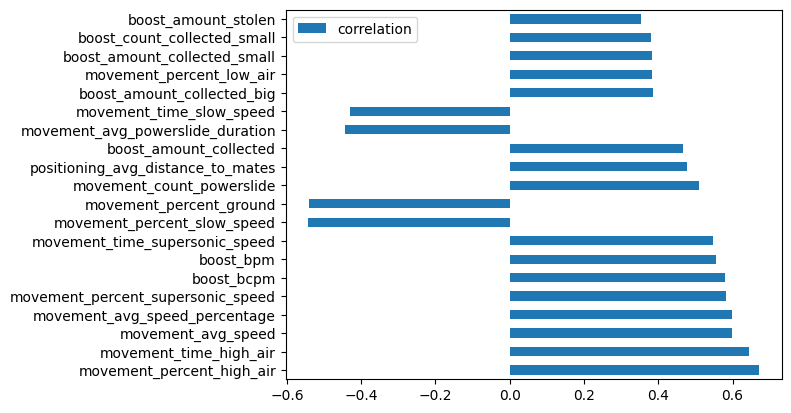

In [26]:
correlation_summary.head(20).plot(kind="barh", y="correlation")

<Axes: xlabel='rank_tier'>

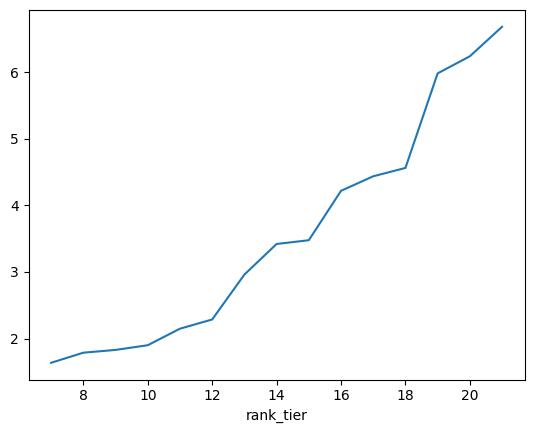

In [27]:
rank_means["movement_percent_high_air"].plot(kind="line")

<Axes: xlabel='rank_tier'>

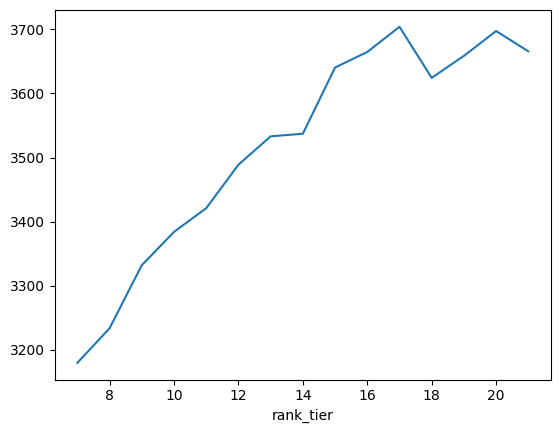

In [28]:
rank_means["positioning_avg_distance_to_mates"].plot(kind="line")

<Axes: xlabel='rank_tier'>

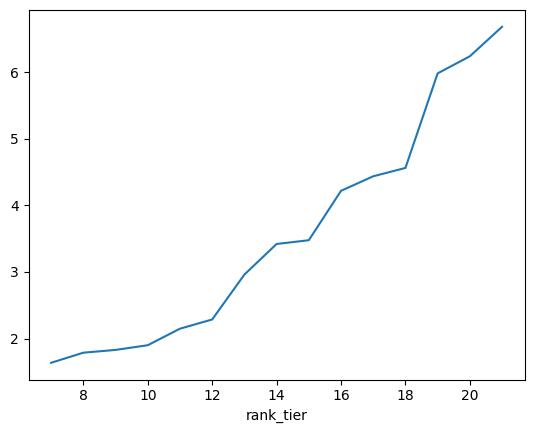

In [29]:
rank_means["movement_percent_high_air"].plot(kind="line")

<Axes: xlabel='rank_tier'>

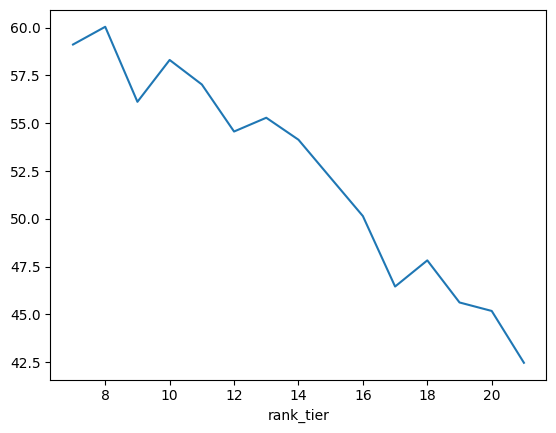

In [30]:
rank_means["movement_percent_slow_speed"].plot(kind="line")


## Early EDA Findings

The dataset contains player-level Rocket League replay stats from Gold 1 through Grand Champion 3. Each rank tier has 102 player rows, except Grand Champion 3, which has 90 rows.

The clearest rank-separating stats are not basic scoreboard stats like goals, assists, or score. Instead, the strongest patterns are related to movement, aerial play, boost usage, and positioning.

The strongest positive correlations with rank are:

- `movement_percent_high_air`
- `movement_time_high_air`
- `movement_avg_speed`
- `movement_percent_supersonic_speed`
- `boost_bcpm`
- `boost_bpm`
- `movement_count_powerslide`
- `positioning_avg_distance_to_mates`

These stats increase as rank increases. This suggests that higher-ranked players play faster, spend more time in the air, use more boost, reach supersonic speed more often, powerslide more often, and maintain more spacing from teammates.

The strongest negative correlations with rank are:

- `movement_percent_slow_speed`
- `movement_percent_ground`
- `movement_time_slow_speed`
- `movement_avg_powerslide_duration`
- `movement_time_ground`
- `positioning_percent_defensive_third`

These stats decrease as rank increases. This suggests that higher-ranked players spend less time moving slowly, less time grounded, and less time stuck in their defensive third.

One interesting finding is that powerslide count increases with rank, but average powerslide duration decreases. This may mean higher-ranked players powerslide more often, but in shorter and more controlled bursts.

Overall, the early EDA suggests that Rocket League rank is separated more by pace, boost activity, aerial involvement, and movement efficiency than by simple scoreboard stats.

In [31]:
model_df = df.copy()

In [32]:
model_df = model_df.drop(columns=[
    "replay_id",
    "rank",
    "team",
])

In [33]:
model_df = model_df.drop(columns=[
    "positioning_goals_against_while_last_defender"
])

In [34]:
model_df.isna().sum().sum()

np.int64(0)

In [35]:
X = model_df.drop(columns=["rank_tier"])
y = model_df["rank_tier"]

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [40]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
y_pred = rf_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.23026315789473684

In [43]:
abs(y_test - y_pred).mean()

np.float64(2.0657894736842106)

In [44]:
(abs(y_test - y_pred) <= 1).mean()

np.float64(0.4901315789473684)

In [45]:
(abs(y_test - y_pred) <= 2).mean()

np.float64(0.6546052631578947)

## First Model Results

I trained a baseline Random Forest classifier to predict exact `rank_tier` from player-level replay stats.

Results:

- Exact tier accuracy: 23.0%
- Within 1 tier accuracy: 49.0%
- Within 2 tiers accuracy: 65.5%
- Mean absolute tier error: 2.07 tiers

Since the model is predicting 15 possible tiers, exact accuracy is harsh. The more useful result is that the model predicts within 1 tier about half the time and within 2 tiers about two-thirds of the time. This suggests that the replay stats contain real rank signal, but exact division prediction is still difficult.

In [46]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
55,movement_percent_high_air,0.026591
59,positioning_avg_distance_to_mates,0.024845
45,movement_time_high_air,0.021935
47,movement_count_powerslide,0.020739
0,duration,0.020410
52,movement_percent_supersonic_speed,0.015981
40,movement_time_supersonic_speed,0.015654
48,movement_avg_powerslide_duration,0.015574
10,boost_bpm,0.015120
11,boost_bcpm,0.014946


## Random Forest Feature Importance

The Random Forest model mostly relied on the same types of stats that appeared in the correlation analysis. The most important features were related to aerial play, movement, boost usage, powersliding, and teammate spacing.

Top features included `movement_percent_high_air`, `positioning_avg_distance_to_mates`, `movement_time_high_air`, `movement_count_powerslide`, `movement_percent_supersonic_speed`, `boost_bpm`, and `boost_bcpm`.

This supports the earlier EDA finding that rank is separated more by pace, aerial involvement, boost activity, and movement efficiency than by basic scoreboard stats.

One possible issue is that `duration` appeared as an important feature. Since game length is not really a player skill stat, future model versions may need to remove `duration` and rely more on percentage or per-minute features.

In [47]:
model_df = model_df.drop(columns=["duration"])

In [48]:
X = model_df.drop(columns=["rank_tier"])
y = model_df["rank_tier"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
rf_model = RandomForestClassifier(random_state=42)

In [51]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
y_pred = rf_model.predict(X_test)

In [53]:
accuracy_score(y_test, y_pred)

0.21710526315789475

In [54]:
abs(y_test - y_pred).mean()

np.float64(2.125)

In [55]:
(abs(y_test - y_pred) <= 1).mean()

np.float64(0.4605263157894737)

In [56]:
(abs(y_test - y_pred) <= 2).mean()

np.float64(0.6776315789473685)

In [57]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
44,movement_time_high_air,0.024751
54,movement_percent_high_air,0.024192
58,positioning_avg_distance_to_mates,0.022824
46,movement_count_powerslide,0.020637
10,boost_bcpm,0.017073
51,movement_percent_supersonic_speed,0.016570
47,movement_avg_powerslide_duration,0.015905
42,movement_time_ground,0.015154
16,boost_amount_collected_small,0.014857
39,movement_time_supersonic_speed,0.014819


## Model After Dropping Duration

I removed `duration` from the model features because game length was only meant to be a replay-quality filter, not a player skill stat.

After removing `duration`, the model performance was:

- Exact tier accuracy: 21.7%
- Within 1 tier accuracy: 46.1%
- Within 2 tiers accuracy: 67.8%
- Mean absolute tier error: 2.13 tiers

The exact accuracy dropped slightly, but the model became conceptually cleaner because it no longer uses game length as a predictor. Feature importance still focused on aerial play, speed, boost usage, powersliding, and spacing.

In [58]:
def tier_to_rank_group(tier):
    if tier <= 9:
        return "gold"
    elif tier <= 12:
        return "platinum"
    elif tier <= 15:
        return "diamond"
    elif tier <= 18:
        return "champion"
    else:
        return "grand_champion"

y_group = model_df["rank_tier"].apply(tier_to_rank_group)

In [59]:
def test_random_forest(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    exact_accuracy = accuracy_score(y_test, y_pred)

    return model, y_test, y_pred, exact_accuracy

In [60]:
exact_model, exact_y_test, exact_y_pred, exact_accuracy = test_random_forest(X, y)

exact_accuracy

0.21710526315789475

In [61]:
group_model, group_y_test, group_y_pred, group_accuracy = test_random_forest(X, y_group)

group_accuracy

0.5328947368421053

## Broad Rank Model

I also tested a simpler target where exact tiers were grouped into broad ranks:

- Gold
- Platinum
- Diamond
- Champion
- Grand Champion

The Random Forest model reached 53.3% accuracy on this broader rank prediction task.

This is much stronger than exact-tier accuracy because the model only has to choose between 5 rank groups instead of 15 exact divisions. This suggests the model is better suited for predicting a player's general rank level than their exact division.

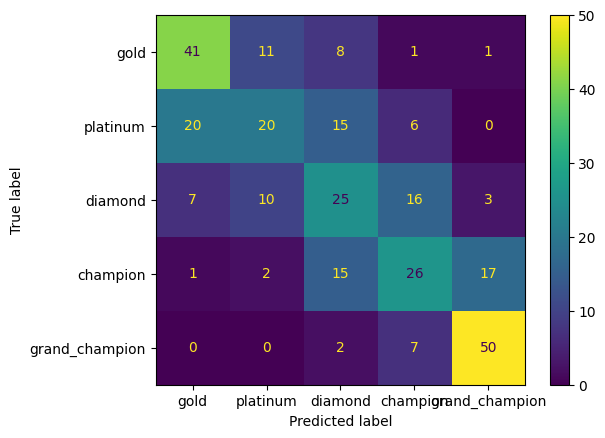

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["gold", "platinum", "diamond", "champion", "grand_champion"]

cm = confusion_matrix(group_y_test, group_y_pred, labels=labels)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
).plot()

## Broad Rank Confusion Matrix

The confusion matrix shows that the model performs best at the extremes.

Gold and Grand Champion are predicted more accurately than the middle ranks. The model correctly predicted 41 Gold players as Gold and 50 Grand Champion players as Grand Champion.

The model struggles more with Platinum, Diamond, and Champion. These ranks are often confused with nearby ranks, which makes sense because the statistical differences between middle ranks are less extreme.

This suggests that the model understands general skill level, but exact boundaries between neighboring ranks are still noisy.

In [63]:
import pickle

with open("../model/model.pkl", "wb") as file:
    pickle.dump(group_model, file)

In [64]:
with open("../model/features.pkl", "wb") as file:
    pickle.dump(list(X.columns), file)